In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

--- Kernel Performance Comparison ---
Linear Kernel Test Accuracy: 46.67%
RBF Kernel Test Accuracy:    98.33%



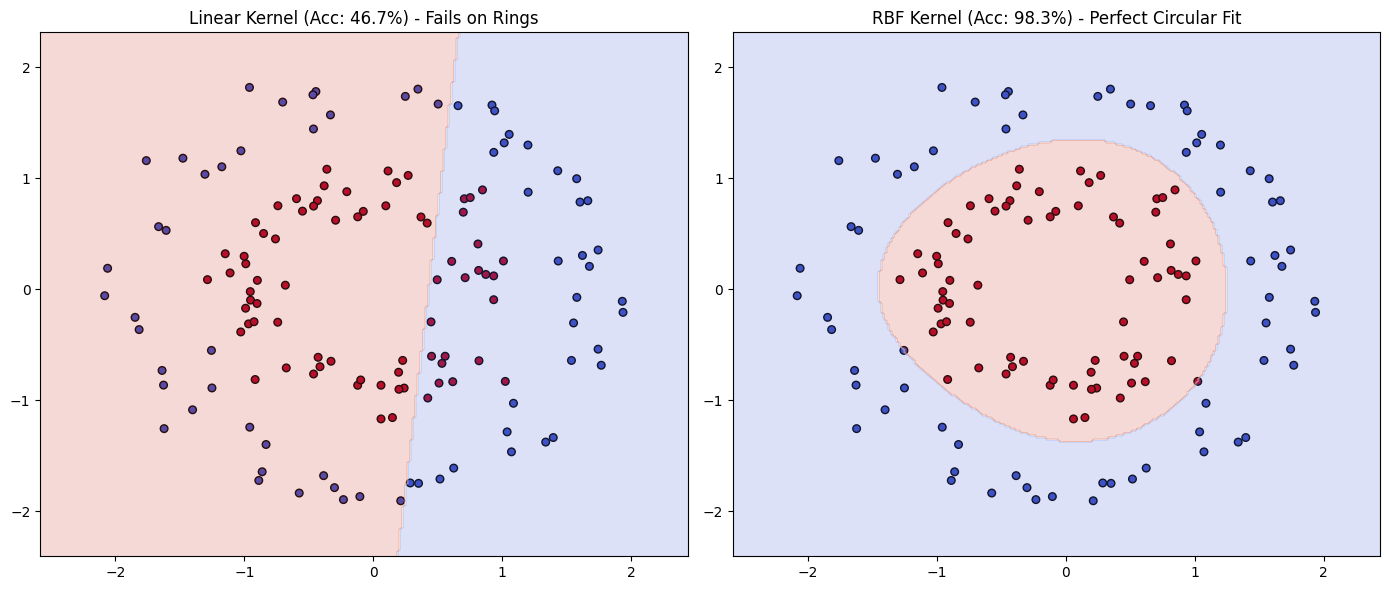

In [2]:
# Topic 117 | SVM - The Kernel Trick Explained
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Ek circular, non-linear dataset generate karein
# Isme ek class ke circles dusri class ke andar trapped hote hain
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling (SVM ke liye zaroori hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# MODEL 1: Linear Kernel (Linear Boundary)
# ------------------------------------------------------------------
linear_svc = SVC(kernel="linear", random_state=42)
linear_svc.fit(X_train_scaled, y_train)
linear_acc = linear_svc.score(X_test_scaled, y_test)

# ------------------------------------------------------------------
# MODEL 2: RBF Kernel (The Kernel Trick Approach)
# ------------------------------------------------------------------
rbf_svc = SVC(kernel="rbf", gamma="scale", random_state=42)
rbf_svc.fit(X_train_scaled, y_train)
rbf_acc = rbf_svc.score(X_test_scaled, y_test)

print("--- Kernel Performance Comparison ---")
print(f"Linear Kernel Test Accuracy: {linear_acc * 100:.2f}%")
print(f"RBF Kernel Test Accuracy:    {rbf_acc * 100:.2f}%\n")


# 2. Decision Boundaries Plot Karne Ka Function
def plot_boundaries(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap="coolwarm", edgecolors="k")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
    ax.set_title(title)


# Plot comparison side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_boundaries(
    linear_svc,
    X_train_scaled,
    y_train,
    axes[0],
    f"Linear Kernel (Acc: {linear_acc*100:.1f}%) - Fails on Rings",
)
plot_boundaries(
    rbf_svc,
    X_train_scaled,
    y_train,
    axes[1],
    f"RBF Kernel (Acc: {rbf_acc*100:.1f}%) - Perfect Circular Fit",
)

plt.tight_layout()
plt.show()

=== HIGH-DIMENSIONAL SVM RESULTS ===
Features ki tadad: 2000
Samples ki tadad:  200
Training Accuracy: 100.00%
Testing Accuracy:  56.67%
Total Support Vectors used: 140

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.43      0.50        30
           1       0.55      0.70      0.62        30

    accuracy                           0.57        60
   macro avg       0.57      0.57      0.56        60
weighted avg       0.57      0.57      0.56        60



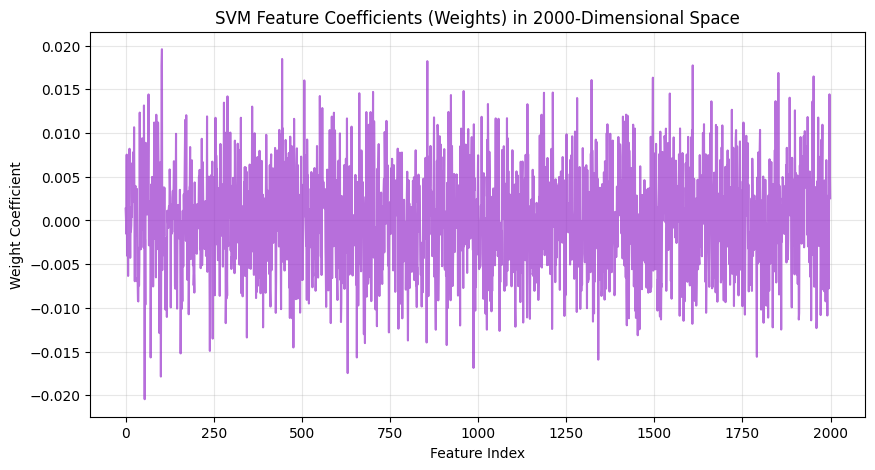

In [3]:
# Topic 118 | SVM - Handling High-Dimensional Data
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. High-Dimensional Dataset generate karein
# Samples sirf 200 hain lekin Features 2000 hain! (n_features >> n_samples)
X, y = make_classification(
    n_samples=200,
    n_features=2000,
    n_informative=20,  # Sirf 20 features kaam ke hain, baki sab noise hai
    n_classes=2,
    random_state=42,
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scaling: High dimensions mein scaling aur bhi zaroori ho jati hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Linear SVM Classifier use karein (High-dim ke liye standard)
# C ko thoda chota rakha hai taake noise control mein rahe (Regularization)
svm_high_dim = SVC(kernel="linear", C=0.1, random_state=42)
svm_high_dim.fit(X_train_scaled, y_train)

# 3. Model Evaluation
train_acc = svm_high_dim.score(X_train_scaled, y_train)
test_acc = svm_high_dim.score(X_test_scaled, y_test)

print("=== HIGH-DIMENSIONAL SVM RESULTS ===")
print(f"Features ki tadad: {X.shape[1]}")
print(f"Samples ki tadad:  {X.shape[0]}")
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")
print(f"Total Support Vectors used: {svm_high_dim.support_vectors_.shape[0]}\n")

# 4. Predictions aur Detailed Report
y_pred = svm_high_dim.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Coefficients (Weights) ki Distribution Plot karein
# Yeh dikhayega ki SVM ne kis tarah fuzool features ke weights ko daba diya hai
coefs = svm_high_dim.coef_.flatten()

plt.figure(figsize=(10, 5))
plt.plot(coefs, color="darkorchid", alpha=0.7)
plt.title("SVM Feature Coefficients (Weights) in 2000-Dimensional Space")
plt.xlabel("Feature Index")
plt.ylabel("Weight Coefficient")
plt.grid(True, alpha=0.3)
plt.show()

Optimizing SVM Pipeline... (Best combinations dhoondi ja rahi hain)

--- Grid Search Results ---
Best Parameters Found: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Training Accuracy: 98.33%

--- Final Evaluation on Test Data ---
Test Set Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



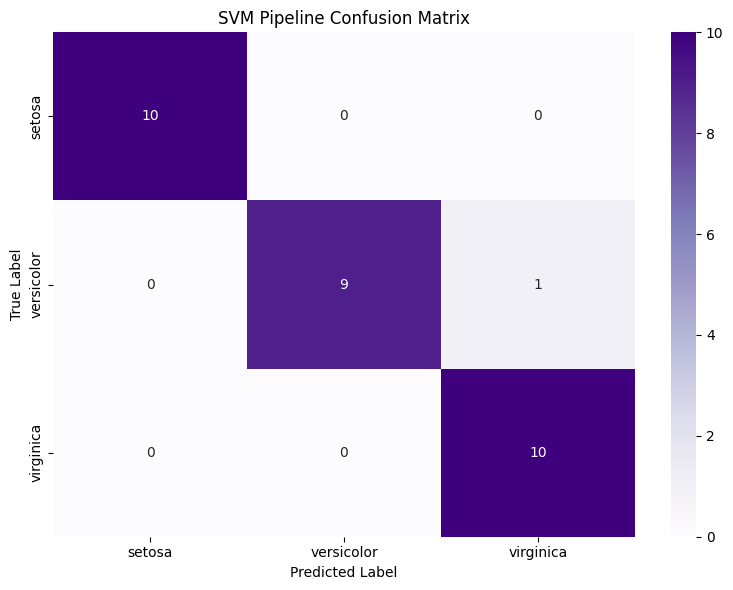

In [4]:
# Topic 119 | SVM - Implementation with Scikit-Learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Dataset load karein (Iris Dataset - 3 Classes)
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# 2. Train-Test Split (80% Train, 20% Test)
# stratify=y classes ki percentage ko dono sets mein barabar rakhta hai
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. FEATURE SCALING (SVM ka sab se critical step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Hyperparameter Grid Define Karein
# Hum linear aur rbf kernels ke sath different C aur gamma values test karenge
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
}

# 5. GridSearchCV Setup aur Training
# cv=5 yani 5-Fold Cross Validation use ho rahi hai
base_svc = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=base_svc, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1
)

print("Optimizing SVM Pipeline... (Best combinations dhoondi ja rahi hain)")
grid_search.fit(X_train_scaled, y_train)

# Best configuration print karein
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best CV Training Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

# 6. Best Model select karein aur predictions nikalyein
best_svm_model = grid_search.best_estimator_
y_pred = best_svm_model.predict(X_test_scaled)

# 7. Model Metrics Evaluation
test_accuracy = best_svm_model.score(X_test_scaled, y_test)
print("--- Final Evaluation on Test Data ---")
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 8. Visualization: Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("SVM Pipeline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()